In [52]:
from scMM.plot.engine import PlotEngine
from scMM.file.data import CyESIData
import numpy as np
save_path = "/home/zby/scMM/data/algea_results/res/0mM"
data = CyESIData("/home/zby/scMM/data/algea_results/deisotope/0mM")#.normalize()#.deisotope()#.annotate(
    #sdf_path="/home/zby/scMM/data/structures_extended.sdf", ppm_tol=5, search_mode="pos")
#data.save("/home/zby/scMM/data/algea_results/deisotope")

In [53]:
import pandas as pd
adata = data.to_anndata()

/home/zby/miniconda3/envs/scMM/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/zby/miniconda3/envs/scMM/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/zby/miniconda3/envs/scMM/lib/python3.11/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [54]:
idf = pd.read_excel("/home/zby/scMM/data/algea_results/SI_annotation_table.xlsx")
adata.var["name"] = None
for i in range(idf.shape[0]):
    name = idf["annotation"].values[i]
    obs_mz = idf["mz"].values[i]
    adata_idx = np.argmin(np.abs(adata.var["mz"].values.astype(float) - obs_mz))
    if name != "unknown":
        adata.var.iloc[adata_idx, adata.var.columns.get_loc("name")] = name
adata.obs["true_time"] = adata.obs["time"].values.astype(float) * 12

In [55]:
engine = PlotEngine.from_adata(adata, fig_path_dir=save_path)
engine.adata.var["class"] = engine.adata.var["name"].map(
    idf.dropna(subset=["annotation", "class"]).drop_duplicates("annotation").set_index("annotation")["class"]
)

/home/zby/miniconda3/envs/scMM/lib/python3.11/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [13]:
engine.pca(n_components=50)
X = engine.umap(use_pca=True, n_neighbors=30, min_dist=0.7)

/home/zby/miniconda3/envs/scMM/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [6]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=data[810.6003], s=0.2)
plt.colorbar()
plt.show()

NameError: name 'X' is not defined

In [ ]:
arg = np.argmin(engine.adata.obsm["X_umap"][:,0])
print(arg)
print(engine.adata.obsm["X_umap"][arg, :])

8548
[4.529227  6.2651663]


In [ ]:
# engine.run_palantir(start_idx = 0, plotting=True, cmap="Spectral_r", use_obsm="X_umap", knn=15)

In [14]:
engine.compute_trajectory(window_size=1000, step_size=300, cell_dist_key="X_umap", 
                          parameterization_key="time", branch_prob_key=None, 
                          store_key="trajectory", plotting=True, cmap="Spectral_r", 
                          title = r"[H$_2$O$_2$] = 1 mM")

In [6]:
engine.metabolic_velocity(window_size=1500, step_size=500, parameterization_key="time", plot=["field", "speed"],
                          s=1, linewidth=1, color_by="time", cmap="viridis")

In [7]:
engine.adata.var["mz"] = engine.adata.var["mz"].astype(float).round(4)
engine.plot_metabolite_trends(parameterization_key="true_time", window_size=1000, step_size=300, kernel_stat="median",
                             feature_name_key="mz", plot_top_n=30, cmap="viridis", xlabel = "Time (h)", ylabel = "m/z")

In [17]:
engine.plot_metabolite_trends(parameterization_key="true_time", window_size=1000, step_size=300, kernel_stat="median",
                             feature_name_key="name", cmap="viridis",
                             xlabel = "Time (h)", ylabel = "Metabolite", plot_top_n=50)

In [18]:
engine.plot_trend_clusters(metric="correlation", cluster_method="leiden", linewidth=2, resolution=1.0, top_k = 150,
                            xlabel = "Time (h)", ylabel = "Relative intensity", feature_name_key="name",
                            max_metabolites_per_cluster = 15, heatmap_cmap="Spectral_r")

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

labels = engine.adata.obs["leiden_cluster"]
time = engine.adata.obs["time"]

cluster_num = pd.to_numeric(labels)
order = np.sort(cluster_num.unique())
df = pd.DataFrame({"cluster": cluster_num,"time": time})

plt.figure(figsize=(6, 5))
sns.violinplot(data=df, x="cluster", y="time", order=order, inner="box", cut=0, palette="Set2")
plt.xlabel("Leiden cluster")
plt.ylabel("True time")
plt.title("True time distribution in each Leiden cluster")
plt.tight_layout()
plt.savefig(f"{save_path}/leiden_cluster_time_distribution.svg", bbox_inches="tight")
plt.close()

/tmp/ipykernel_328143/742485224.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="cluster", y="time", order=order, inner="box", cut=0, palette="Set2")


In [5]:
engine.plot_feature_pair_scatter(
    name_key="name",
    feature_a="Chlorophyll a",
    feature_b="Chlorophyll b",
    color_key="true_time",
    alpha=0.9,
    cmap="viridis",
    scatter_size=1,
    xlim=(0,0.02),
    ylim=(0,0.005),
    regression=False
)

In [7]:
obs_range=(3,12)
engine.feature_network(
    name_key="name",
    class_key="class",
    metric="pearson",
    alpha=0.3,
    obs_key="true_time",
    obs_range=obs_range,
    figsize = (8, 6),
    top_nodes=None,
    edge_threshold=0.5,
    min_class_size=5,
    node_size_base=100,
    node_size_multiplier=800,
    node_size_legend_range=(0, 0.12),
    node_size_legend_n=3,
    edge_width_multiplier=2.5,
    edge_width_min=0.2,
    edge_alpha=0.35,
    show_labels=False,
    legend_bbox_to_anchor=(1.35, 0.5),
    legend_loc="center left",
    tight_layout_rect=[0, 0, 0.75, 1],
    colorbar_label="Pearson correlation",
    layout_k=2.5,
    radial_compress=0.2,
    numbered_nodes=["Chlorophyllide a", "Chlorophyllide b", "Chlorophyll a", "Chlorophyll b", "Pheophytin a"],
)

(<networkx.classes.graph.Graph at 0x7fbbdce9a9d0>,
 {'selection_mode': 'obs_range',
  'selection_label': 'true_time_3_12',
  'obs_key': 'true_time',
  'obs_range': (3, 12),
  'target_label': None,
  'label_key': None,
  'include_left': True,
  'include_right': False,
  'colorbar_vmin': -0.6784039568351201,
  'colorbar_vmax': 0.9772491744679754,
  'edge_vmin': -0.6784039568351201,
  'edge_vmax': 0.9772491744679754,
  'n_nodes': 170,
  'n_edges': 894,
  'n_samples': 13969,
  'n_selected_samples': 13969,
  'n_features_total_in_adata': 994,
  'n_features_after_annotation_filter': 261,
  'n_features_removed_unannotated': 733,
  'n_all_zero_features': 0,
  'n_zero_variance_features': 0,
  'n_features_used_for_model': 261,
  'n_features_excluded_from_model': 0,
  'annotated_only': True,
  'min_class_size': 5,
  'other_label': 'Other',
  'layout_k': 2.5,
  'layout_iterations': 300,
  'layout_scale': 1.0,
  'compact_layout': True,
  'radial_compress': 0.2,
  'numbered_nodes_requested': ['Chloro

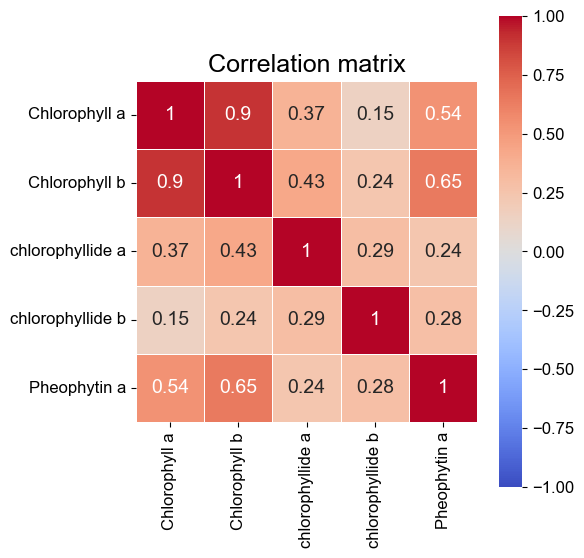

In [60]:
mets = [
    "Chlorophyll a",
    "Chlorophyll b",
    "chlorophyllide a",
    "chlorophyllide b",
    "Pheophytin a"
]

net_key = list(engine.adata.uns["network"].keys())[-1]
net = engine.adata.uns["network"][net_key]

corr = pd.DataFrame(
    net["correlation_matrix"],
    index=net["var_for_network"][net["name_key"]].astype(str).values,
    columns=net["var_for_network"][net["name_key"]].astype(str).values,
)

sub_corr = corr.loc[mets, mets]
np.fill_diagonal(sub_corr.values, 1)

sub_corr

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 6))
sns.heatmap(
    sub_corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)
plt.title("Correlation matrix")
plt.tight_layout()
plt.savefig(f"{engine.path}/selected_metabolite_correlation_matrix_heatmap_{obs_range}.svg", bbox_inches="tight")
plt.show()

In [7]:
engine.plot_single_metabolite_trend(
    name_key="name",
    metabolite_name="Chlorophyll a",
    time_key="true_time",
    scatter_alpha = 0.3,
    scatter_size = 2,
    ci_alpha = 0.5,
    ci = 99,
    line_color="red",
    output_file=f"{save_path}/Chlorophyll_a_trend.svg"
)

In [24]:
import numpy as np
import matplotlib.pyplot as plt

compound_a = "Chlorophyll a"
compound_b = "Chlorophyll b"
feature1 = engine.adata.X[:, engine.adata.var["name"] == compound_a]
feature2 = engine.adata.X[:, engine.adata.var["name"] == compound_b]

if hasattr(feature1, "toarray"):
    feature1 = feature1.toarray()
if hasattr(feature2, "toarray"):
    feature2 = feature2.toarray()

feature1 = np.asarray(feature1).ravel()
feature2 = np.asarray(feature2).ravel()

finite_mask = (
    np.isfinite(feature1)
    & np.isfinite(feature2)
    & (feature1 != 0)
    & (feature2 != 0)
)

x = engine.adata.obs["true_time"].values[finite_mask]
y = feature1[finite_mask] / feature2[finite_mask]

engine.plot_xy_scatter(
    x=x,
    y=y,
    xlabel="Time (h)",
    ylabel=f"{compound_a} / {compound_b}",
    scatter_alpha=0.3,
    scatter_size=4,
    density_color = True,
    kernel_regression = True,
    bandwidth=0.3,
    log1p_y=True,
    xlim=(0,12),
    density_method="hexbin",
    density_cmap="viridis",
    density_gridsize=65,
    output_file=f"{save_path}/{compound_a}_to_{compound_b}_ratio.svg"
)

In [57]:
class_colors = {
    "DGTS": "#c49c94",                        # blue
    "MGDG": "#aec7e8",                         # light blue
    "DG": "#ff7f0e",                           # orange
    "LPI": "#2ca02c",                          # green
    "Carotenoids": "#98df8a",                  # light green
    "TG": "#ff9896",                           # light red / salmon
    "DGDG": "#9467bd",                         # purple
    "Chlorophyll and Derivatives": "#8c564b",  # brown
    "PG": "#1f77b4",                            # light brown
    "PE": "#e377c2",                           # pink
    "MGTS": "#7f7f7f",                         # gray
    "ST": "#c7c7c7",                           # light gray
    "SQDG": "#dbdb8d",                         # pale olive
    "PI": "#17becf",                           # cyan
    "amino acid": "#9edae5",                   # light cyan
    "Other": "#bdbdbd",                        # neutral gray
}
engine.plot_class_composition_over_time(
    time_key="true_time",
    class_key="class",
    bin_width=0.2,   # 10 min bins
    event_time=1.0,
    xlabel="Time (h)",
    ylabel="Relative lipid-class composition",
    figsize=(10,6),
    min_class_total=3,
    colors = class_colors,
    y_compress_regions=[(0.0, 0.75, 0.25)],
)

In [63]:
name_key = "name"     # 改成你的注释列
class_key = "class"   # 改成你的类别列

import re
def parse_lipid_carbon_db(x):
    if pd.isna(x):
        return np.nan, np.nan
    s = str(x)
    m = re.search(r"(?<!\d)(\d{2,3})\s*:\s*(\d+)", s)
    if m is None:
        return np.nan, np.nan
    return float(m.group(1)), float(m.group(2))

carbon_db = engine.adata.var[name_key].apply(parse_lipid_carbon_db)
engine.adata.var["carbon_number"] = [x[0] for x in carbon_db]
engine.adata.var["double_bond"] = [x[1] for x in carbon_db]

is_dgts = engine.adata.var[class_key].astype(str).eq("DGTS")
has_db = engine.adata.var["double_bond"].notna()

high_db = (is_dgts & has_db & (engine.adata.var["carbon_number"] == 36)).values
low_db  = (is_dgts & has_db & (engine.adata.var["carbon_number"] == 32)).values

X = engine._get_X().astype(float)
X = np.where(X < 0, 0, X)

high_sum = np.nansum(X[:, high_db], axis=1)
low_sum = np.nansum(X[:, low_db], axis=1)

ratio = high_sum / (low_sum + 1e-12)

y = ratio#np.log10(ratio + 1e-12)
y_mask = (y < 15)

time_key="true_time"
engine.plot_xy_scatter(
    x=engine.adata.obs[time_key].values[y_mask],
    y=y[y_mask],
    xlabel="Time (h)",
    ylabel="DGTS(length = 36 / length = 32)",
    title="DGTS total chain length shift over time",
    density_color=True,
    linear_regression=False,
    kernel_regression=True,
    figsize=(5, 5),
    xlim=(0,12),
    output_file=f"{engine.path}/DGTS_CL_36_over_32_scatter.svg",
)

In [59]:
total_DGTS = engine.adata.X[:, engine.adata.var["class"] == "DGTS"].sum(axis=1)
total_ST = engine.adata.X[:, engine.adata.var["class"] == "ST"].sum(axis=1)
finite_mask = (
    np.isfinite(total_DGTS)
    & np.isfinite(total_ST)
    & (total_DGTS != 0)
    & (total_ST != 0)
)
engine.plot_xy_scatter(
    x=engine.adata.obs[time_key].values[finite_mask],
    y=total_ST[finite_mask]/total_DGTS[finite_mask],
    xlabel="Time (h)",
    ylabel="ST/DGTS",
    density_color=True,
    linear_regression=False,
    kernel_regression=True,
    figsize=(5, 5),
    bandwidth=0.1,
    xlim=(0,12),
    output_file=f"{engine.path}/DGTS_ST_ratio_scatter.svg",
)

In [26]:
engine.plot_metabolite_entropy(
    feature="Chlorophyll a",
    ratio_to="Chlorophyll b",
    include_zero = False,
    feature_name_key="name",
    parameterization_key="true_time",
    window_size=1000,
    step_size=300,
    output_file=f"{engine.path}/Chlorophyll_a_to_Chlorophyll_b_entropy.svg"
)

In [18]:
engine.plot_cell_state_dispersion(
    parameterization_key="true_time",
    use_rep="X_pca",
    n_components=10,
    window_size=300,
    step_size=100,
    output_file=f"{engine.path}/cell_dispersion.svg"
)

In [30]:
engine.cluster_cells(method="leiden", n_neighbors=20, resolution=0.25, key_added="leiden_cluster")
engine.plot_cluster_time_distribution(cluster_key="leiden_cluster", parameterization_key="true_time", window_size=1000, step_size=300)

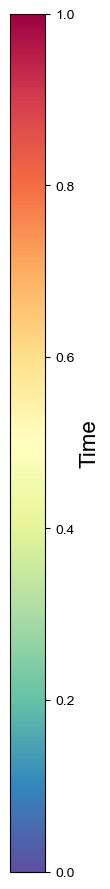

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, ax = plt.subplots(figsize=(1.2, 9))

norm = mpl.colors.Normalize(vmin=0, vmax=1)
cbar = mpl.colorbar.ColorbarBase(
    ax,
    cmap="Spectral_r",
    norm=norm,
    orientation="vertical"
)

cbar.set_label("Time", size=16)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig("bar.svg")